In [82]:
import pandas as pd

df = pd.read_csv("ChocolateSales.csv")

df.tail(30)



,Sales Person,Country,Product,Date,Amount,Boxes Shipped
3252,Gigi Bohling,USA,70% Dark Bites,14/01/2024,"$8,561.59",204
3253,Rafaelita Blaksland,Australia,White Choc,21/03/2024,"$7,326.91",102
3254,Roddy Speechley,Canada,Drinking Coco,17/05/2024,"$8,196.93",340
3255,Camilla Castle,New Zealand,85% Dark Bars,08/08/2024,"$17,841.92",53
3256,Madelene Upcott,Canada,Milk Bars,26/04/2024,"$4,285.13",87
3257,Madelene Upcott,Australia,70% Dark Bites,15/04/2024,"$4,196.23",256
3258,Oby Sorrel,Canada,Eclairs,19/05/2024,"$6,409.31",621
3259,Dennison Crosswaite,Canada,Drinking Coco,10/01/2024,"$3,010.07",24
3260,Mallorie Waber,New Zealand,After Nines,04/05/2024,$567.91,225
3261,Roddy Speechley,Canada,White Choc,05/04/2024,"$6,948.79",292


In [83]:
df.dtypes

Sales Person     object
Country          object
Product          object
Date             object
Amount           object
Boxes Shipped     int64
dtype: object

In [84]:
df['Amount'] = df['Amount'].str.replace('$', '').str.replace(',', '').astype(float)

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)



In [85]:
df.dtypes

Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                  float64
Boxes Shipped             int64
dtype: object

In [86]:
df.describe()



,Date,Amount,Boxes Shipped
count,3282,3282.000000,3282.000000
mean,2023-05-03 15:09:06.252284928,6030.338775,164.666971
min,2022-01-03 00:00:00,7.000000,1.000000
25%,2022-07-04 00:00:00,2521.495000,71.000000
50%,2023-05-11 00:00:00,5225.500000,137.000000
75%,2024-03-02 00:00:00,8556.842500,232.000000
max,2024-08-31 00:00:00,26170.950000,778.000000
std,NaN,4393.980200,124.024736


In [87]:
df.nunique()

Sales Person       25
Country             6
Product            22
Date              504
Amount           3013
Boxes Shipped     507
dtype: int64

<Axes: xlabel='Date'>

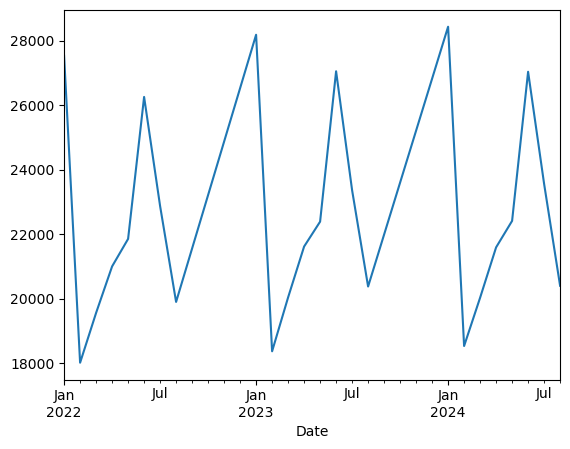

In [88]:
monthly = df.groupby(df['Date'].dt.to_period('M'))['Boxes Shipped'].sum()
monthly.plot()

<Axes: xlabel='Date'>

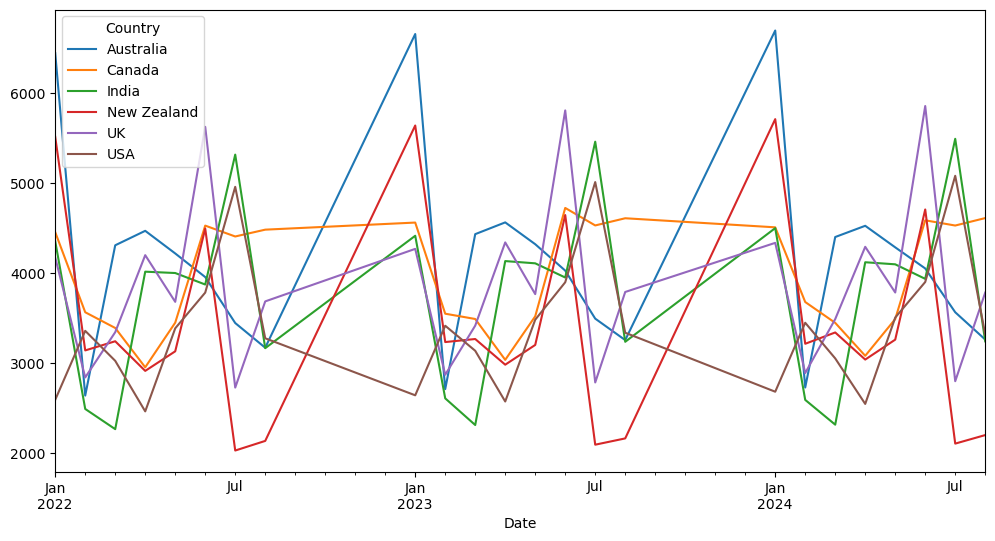

In [89]:
monthly_country = df.groupby([df['Date'].dt.to_period('M'), 'Country'])['Boxes Shipped'].sum()
monthly_country = monthly_country.unstack()
monthly_country.plot(figsize=(12,6))

In [90]:
df.groupby('Country')['Boxes Shipped'].sum()

Country
Australia      99618
Canada         95158
India          89968
New Zealand    81350
UK             92523
USA            81820
Name: Boxes Shipped, dtype: int64

In [91]:
anz = df[df['Country'].isin(['Australia', 'New Zealand'])].copy()
anz['Sales Person'].value_counts()

Sales Person
Brien Boise            60
Madelene Upcott        57
Barr Faughny           51
Beverie Moffet         51
Ches Bonnell           51
Wilone O'Kielt         51
Mallorie Waber         48
Karlen McCaffrey       48
Marney O'Breen         48
Gigi Bohling           48
Kelci Walkden          48
Curtice Advani         45
Dotty Strutley         45
Oby Sorrel             45
Van Tuxwell            45
Dennison Crosswaite    45
Rafaelita Blaksland    42
Camilla Castle         42
Kaine Padly            42
Roddy Speechley        39
Andria Kimpton         39
Gunar Cockshoot        39
Jehu Rudeforth         39
Husein Augar           33
Jan Morforth           33
Name: count, dtype: int64

<Axes: xlabel='Month'>

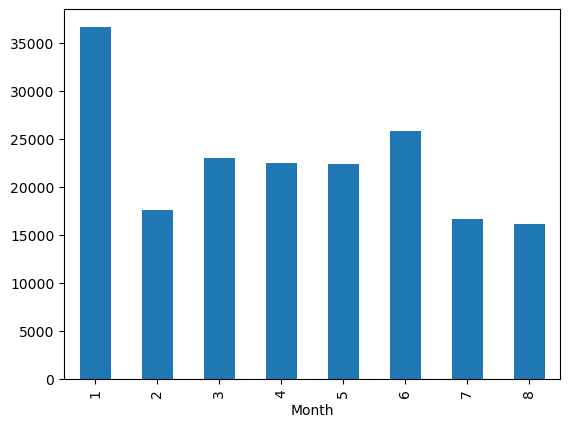

In [92]:
anz['Month'] = anz['Date'].dt.month
anz.groupby('Month')['Boxes Shipped'].sum().plot(kind='bar')

In [93]:
anz['Month'].unique()

array([4, 3, 7, 8, 1, 6, 2, 5], dtype=int32)

In [94]:
df.groupby(['Country', df['Date'].dt.month])['Boxes Shipped'].sum().unstack()


Date,1,2,3,4,5,6,7,8
Country,,,,,,,,
Australia,19812,8067,13143,13560,12825,12033,10498,9680
Canada,13526,10787,10321,9061,10452,13840,13466,13705
India,13269,7677,6879,12268,12205,11757,16277,9636
New Zealand,16873,9581,9843,8925,9585,13849,6211,6483
UK,12778,8590,10242,12832,11227,17299,8300,11255
USA,7904,10215,9205,7570,10368,11579,15056,9923


In [95]:
monthly = df.groupby(df['Date'].dt.to_period('M'))['Boxes Shipped'].sum()
print(monthly)

Date
2022-01    27535
2022-02    18015
2022-03    19561
2022-04    21003
2022-05    21856
2022-06    26260
2022-07    22876
2022-08    19901
2023-01    28189
2023-02    18369
2023-03    20041
2023-04    21619
2023-05    22391
2023-06    27056
2023-07    23367
2023-08    20379
2024-01    28438
2024-02    18533
2024-03    20031
2024-04    21594
2024-05    22415
2024-06    27041
2024-07    23565
2024-08    20402
Freq: M, Name: Boxes Shipped, dtype: int64
